# 💳 Credit Card Fraud Detection using Machine Learning

## 📌 Project Overview

Credit card fraud is one of the most significant challenges in the financial industry, resulting in substantial monetary losses each year. With the rapid growth of online transactions, identifying fraudulent activities has become increasingly important. Since fraudulent transactions represent only a very small percentage of all transactions, detecting them is a challenging imbalanced classification problem.

This project aims to analyze historical credit card transaction data, understand the characteristics of fraudulent transactions through Exploratory Data Analysis (EDA), and build an effective machine learning model capable of accurately distinguishing fraudulent transactions from legitimate ones.

---

## 🎯 Objectives

- Perform comprehensive Exploratory Data Analysis (EDA).
- Understand the structure and quality of the dataset.
- Identify missing values and duplicate records.
- Analyze the distribution of transaction amounts and transaction times.
- Examine the class imbalance between legitimate and fraudulent transactions.
- Explore relationships among features using statistical analysis and visualizations.
- Generate business insights from the data.
- Prepare the dataset for preprocessing and machine learning.

---

## 📂 Dataset Information

- **Dataset Name:** Credit Card Fraud Detection
- **Total Transactions:** 284,807
- **Total Features:** 31
- **Target Variable:** `Class`
  - **0** → Legitimate Transaction
  - **1** → Fraudulent Transaction

Most features (`V1`–`V28`) have been transformed using **Principal Component Analysis (PCA)** to protect sensitive customer information. The only original features are:

- **Time** – Seconds elapsed between each transaction and the first transaction.
- **Amount** – Transaction amount.
- **Class** – Target variable indicating whether a transaction is fraudulent.

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

## 📖 Notebook Workflow

1. Import Required Libraries
2. Load the Dataset
3. Basic Data Exploration
4. Data Quality Assessment
5. Missing Value Analysis
6. Duplicate Record Analysis
7. Statistical Summary
8. Class Distribution Analysis
9. Transaction Amount Analysis
10. Transaction Time Analysis
11. Correlation Analysis
12. Feature Distribution
13. Business Insights
14. Key Findings

---

## 🎯 Expected Outcome

By the end of this notebook, we will have a thorough understanding of the dataset, identify important patterns, detect potential issues, and prepare a clean foundation for preprocessing and machine learning model development in the following notebooks.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("D:\CreditCardFraudDetection\data\creditcard.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
rows, columns = df.shape

print(f"Number of Rows : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows : 284807
Number of Columns : 31


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,115785.996110,0.882601,0.790333,1.254122,1.275412,-0.736424,0.978021,-0.381052,-2.427109,-1.115195,0.372661,0.412888,-1.040884,0.250743,0.202383,0.187478,-0.330262,1.854718,-0.259490,0.521256,-0.965438,1.201532,-0.564609,-1.822660,0.142062,1.265317,-0.815931,0.040751,0.464904,4.992092,0
1,30599.867266,-0.578386,-0.020084,-0.414409,-1.185854,-0.232219,0.835568,0.904599,-0.253787,0.779049,0.847725,-1.193357,0.131328,0.209529,-0.212899,0.178410,-0.761817,-1.077479,0.623369,1.394548,-1.190955,0.293120,-0.095091,0.100822,0.245374,-0.546046,-0.465535,1.716052,-0.114050,4.746681,0
2,85460.037236,-0.250057,2.107963,-0.609275,0.377194,0.225668,-0.360649,-0.430408,1.373593,0.173004,0.256674,-0.666306,0.594480,1.931776,-1.629614,-0.938679,2.624138,0.504614,0.640105,-0.478066,1.416307,-0.168771,-0.488810,-3.257683,-0.572529,0.276721,-0.525678,0.379281,1.080225,21.977584,0
3,158012.696820,0.579010,1.074230,-1.852265,0.433697,0.800022,0.057146,0.126488,-0.311685,-1.685027,-0.347022,0.724411,1.997488,-0.907223,0.040751,1.488461,0.393563,0.625249,0.293406,-0.027663,-0.470080,-0.249056,-0.716691,0.363351,-0.251082,1.185452,0.172348,-0.151179,0.252404,1.536829,0
4,6907.989732,0.144364,0.411880,0.046726,-0.248358,0.499114,-1.279432,-0.596260,-0.257995,-1.198916,0.231395,-0.258582,-0.503580,0.712685,-0.469985,-1.439789,-0.113609,-2.597154,0.032245,0.686051,-0.483257,-1.295457,-0.029933,-0.785744,-1.600805,-0.303094,-1.596602,0.108353,-0.230522,40.300253,0


In [5]:
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,14692.165150,-0.212498,1.339782,0.449144,-1.099577,0.841489,0.220188,0.787906,-0.031439,-0.710837,1.284877,-0.412143,-0.168221,-1.385512,-0.465148,0.914846,2.456955,-0.815176,-0.532725,1.062120,0.825686,0.197410,0.858473,-0.780872,-1.048762,-0.695719,0.502328,-0.124678,0.006266,21.473635,0
284803,94320.659650,-0.215879,-0.603065,-0.786387,1.157631,-0.930011,-1.464266,0.336221,-0.478571,-0.275634,1.475141,0.401610,-0.830238,-1.395900,1.406911,-0.389433,0.749260,-0.722213,0.281895,1.673830,0.921007,-0.593203,0.776394,-0.929441,-0.591254,0.789460,0.690655,1.239012,-2.545699,6.670332,0
284804,64638.262274,-0.799447,-0.877559,0.234339,-0.078053,-0.211463,-1.082114,-1.847054,0.734683,-0.526716,0.053420,1.583295,-0.733828,-0.158938,-0.355339,-3.878736,-1.218069,0.493642,0.682818,0.491503,0.682684,-1.998626,0.160990,-0.415726,1.107771,0.630047,0.587608,-0.614421,-1.908481,83.307497,0
284805,149627.776188,0.898233,-0.724577,-1.561830,1.433125,0.034358,-0.967690,-0.877779,-0.067735,-0.703174,0.067304,-1.000404,-0.027687,-0.641940,-0.926290,-0.684301,2.683452,0.993346,-0.546923,0.927738,1.175053,1.576220,0.143460,0.069058,0.140130,-0.183205,1.365936,1.036116,-0.790683,1.288562,0
284806,6522.083869,0.635542,2.047187,-1.167048,0.099101,-0.593915,1.851896,1.454889,-0.169430,0.658348,-0.031836,-0.874928,0.459045,2.201305,2.127530,1.093895,1.137026,-0.863782,-1.543331,0.421383,-1.707943,0.150529,0.254559,-0.948606,0.319216,-0.153143,0.028444,-0.303392,0.424291,66.079170,0


In [6]:
df.sample(10, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,92495.523553,1.923223,1.657657,-0.195796,1.513695,1.765097,-0.240884,0.321832,0.667499,0.854609,-0.081222,-0.271761,-0.321604,1.094105,-0.308475,1.872198,-1.802072,0.410363,1.028441,1.059444,0.752058,0.984111,0.071776,-1.025168,-0.994524,0.402034,-0.534734,-1.264512,1.591245,85.254344,0
49906,168249.334102,0.782789,-0.818187,-2.437162,-1.237058,-1.616461,-0.865685,-1.132365,-0.091258,-0.842315,1.466742,-0.353708,-0.610657,-0.310400,0.790580,-0.183833,-0.461659,-1.550132,1.467928,0.719357,-1.343041,-0.278089,0.803798,-1.026082,2.338963,0.062354,0.253026,-1.095695,-1.036850,30.057672,0
29474,56409.460709,-0.680859,-0.506391,-0.296357,0.240633,-1.216206,-0.119698,-0.982560,0.490505,-1.028860,-0.700545,0.386908,0.118359,-0.812262,-0.064886,-0.645484,-0.655314,-0.783245,1.524870,0.093967,0.104397,-0.016599,-0.814934,1.079517,-0.034967,-0.906468,0.401908,-0.805821,0.238090,16.759814,0
276481,160314.753866,1.335195,0.185321,0.243398,-0.206677,0.790608,-0.809669,1.013097,1.579371,0.094264,-0.849051,-0.132879,-0.645839,-0.631454,-0.536893,-1.499079,0.182403,-0.252220,-1.456143,0.208259,1.137829,-1.501266,-0.035391,2.324496,-1.730667,-0.148135,0.560347,-0.853513,-0.643506,2.572966,0
278846,99438.753466,0.056516,1.652151,0.828513,-1.643662,1.789861,0.485949,0.824549,1.439765,0.816407,0.688150,0.207253,2.131695,-1.648135,0.976254,1.248073,0.726202,0.506327,-1.441482,-0.162307,1.208637,0.380954,0.747886,0.054969,1.063697,-0.569603,0.342197,-0.532442,0.250772,3.529795,0
101565,34305.950076,-0.061730,1.441552,0.533516,-0.272610,1.903865,-0.966486,0.528796,0.201153,0.717650,1.119224,0.845534,-0.576249,0.883483,-1.114289,-0.148192,-1.047742,0.815241,-0.871727,0.457840,0.720679,-0.563531,-0.194206,0.757794,0.523176,-0.700036,2.555822,-0.827830,-0.181604,123.289394,0
260880,46738.646655,-0.757205,0.226952,0.234089,1.485017,-1.260976,0.173528,1.178950,0.357231,-1.064609,0.533284,0.109247,-0.856200,-0.754650,0.844614,0.046616,2.189192,-0.201517,-0.707487,0.982384,0.047070,-0.338403,0.624096,1.515716,-1.143527,0.928600,0.083528,1.785358,-0.063959,16.978203,0
214337,45021.387429,-0.771029,-1.372503,1.006773,-0.028791,-1.523596,-0.274073,-0.019660,-1.360204,-0.875601,0.995545,0.276606,0.225291,-0.743505,-1.592755,0.528187,1.200233,1.478174,-0.252797,1.174411,0.582916,1.540134,-0.754731,-1.300166,-0.806507,-1.044871,2.181535,-0.718602,0.306684,5.365678,0
201575,46404.125473,-0.092866,0.466532,-0.858500,-0.843554,-0.629433,0.400128,-0.124814,0.345578,0.315189,-2.929900,0.499331,1.050136,-1.607440,1.288272,0.361369,1.498687,-0.653719,0.497886,1.553320,0.713177,-1.836399,0.184931,-1.475544,0.149408,0.377514,0.498361,-0.571459,0.076064,77.801689,0
81055,34071.641820,-2.341022,-0.324701,-1.206485,0.358985,-0.926522,-1.526594,-0.848728,-1.980466,-0.472258,0.946759,-0.522751,-0.240193,1.657383,-0.654899,-0.653322,-0.488976,1.336830,-0.330338,1.141784,-0.178782,0.826861,0.974917,-1.825520,0.323469,-1.605478,2.645275,0.591204,0.248581,9.385786,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [9]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,86484.695039,49874.319589,0.397108,43236.711087,86590.891761,129648.084118,172790.624974
V1,284807.0,-0.005791,1.027883,-12.366661,-0.676352,0.000933,0.676997,5.179307
V2,284807.0,0.006058,1.014728,-4.709601,-0.675527,0.002175,0.678482,9.286877
V3,284807.0,-0.004731,1.018620,-11.694340,-0.678342,-0.001248,0.675740,4.409629
V4,284807.0,0.006354,1.018878,-4.395903,-0.673314,0.000230,0.676112,9.415583
V5,284807.0,-0.001143,0.999751,-5.034022,-0.672644,0.001292,0.674881,4.642852
V6,284807.0,0.000894,0.998007,-4.408343,-0.672060,-0.001142,0.674226,4.431776
V7,284807.0,-0.006228,1.002989,-7.527053,-0.678491,-0.006417,0.670131,4.718606
V8,284807.0,-0.002861,1.000719,-4.381909,-0.677686,-0.001957,0.673965,4.429720
V9,284807.0,-0.002282,1.002682,-6.040101,-0.676962,-0.001521,0.675254,4.291597


In [11]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0


In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [13]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")

df.shape

Duplicates Removed Successfully


(284807, 31)

In [14]:
memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory Usage : {memory:.2f} MB")

Memory Usage : 67.36 MB


In [15]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [16]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

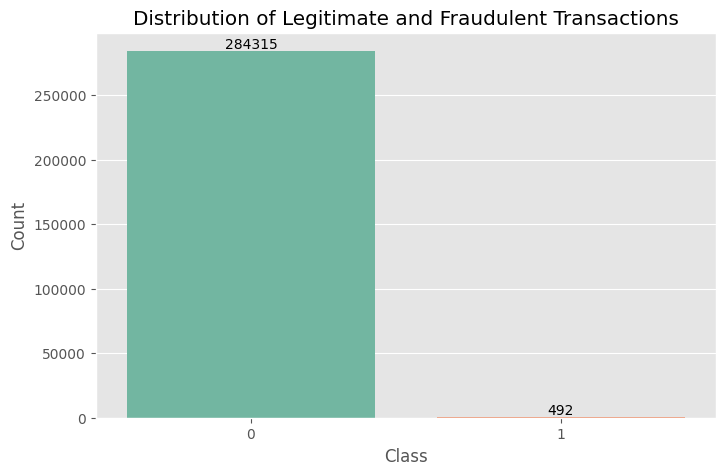

In [17]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Class",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

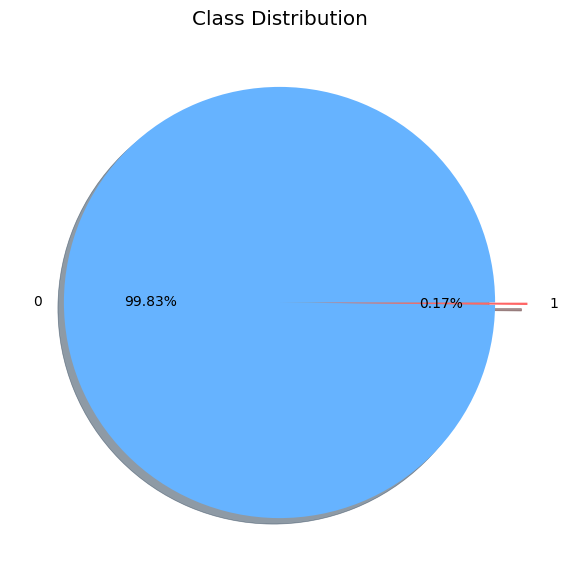

In [18]:
plt.figure(figsize=(7, 7))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    explode=[0, 0.15],
    colors=["#66b3ff", "#ff6666"],
    shadow=True
)

plt.title("Class Distribution")
plt.ylabel("")

plt.show()

In [19]:
legitimate = df[df["Class"] == 0].shape[0]
fraud = df[df["Class"] == 1].shape[0]

print(f"Legitimate Transactions : {legitimate}")
print(f"Fraud Transactions : {fraud}")
print(f"Fraud Percentage : {(fraud / len(df)) * 100:.4f}%")

Legitimate Transactions : 284315
Fraud Transactions : 492
Fraud Percentage : 0.1727%


# 💰 Transaction Amount Analysis

In this section, we analyze the distribution of transaction amounts to understand spending behavior, identify skewness, detect potential outliers, and compare legitimate and fraudulent transactions.

In [20]:
df["Amount"].describe().T

count    284807.000000
mean         61.656961
std         176.646598
min           0.031679
25%           7.256215
50%          20.029080
75%          55.037991
max       20436.737589
Name: Amount, dtype: float64

In [21]:
print(f"Minimum Amount : ${df['Amount'].min():.2f}")
print(f"Maximum Amount : ${df['Amount'].max():.2f}")
print(f"Average Amount : ${df['Amount'].mean():.2f}")
print(f"Median Amount  : ${df['Amount'].median():.2f}")

Minimum Amount : $0.03
Maximum Amount : $20436.74
Average Amount : $61.66
Median Amount  : $20.03


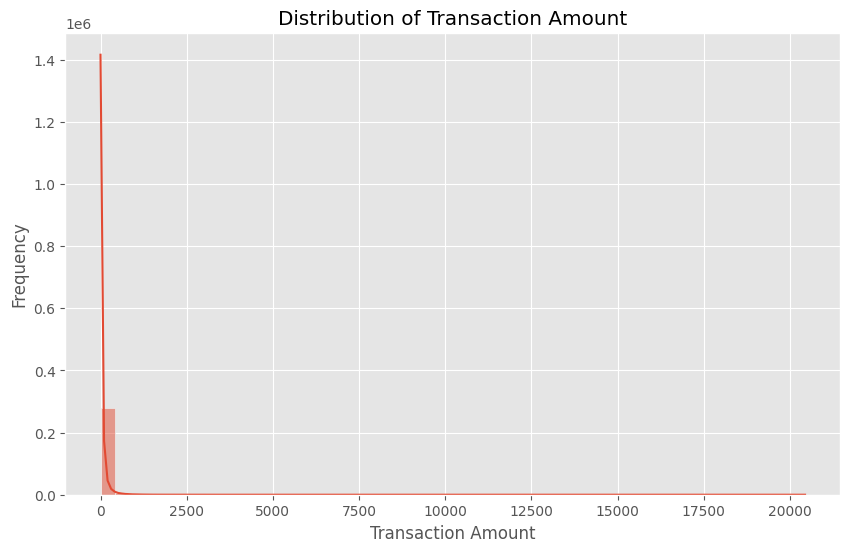

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

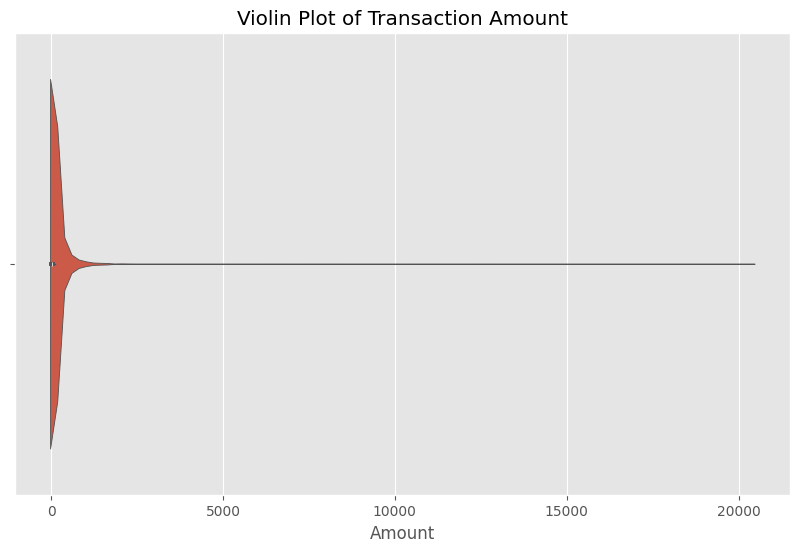

In [23]:
plt.figure(figsize=(10,6))

sns.violinplot(x=df["Amount"])

plt.title("Violin Plot of Transaction Amount")

plt.show()

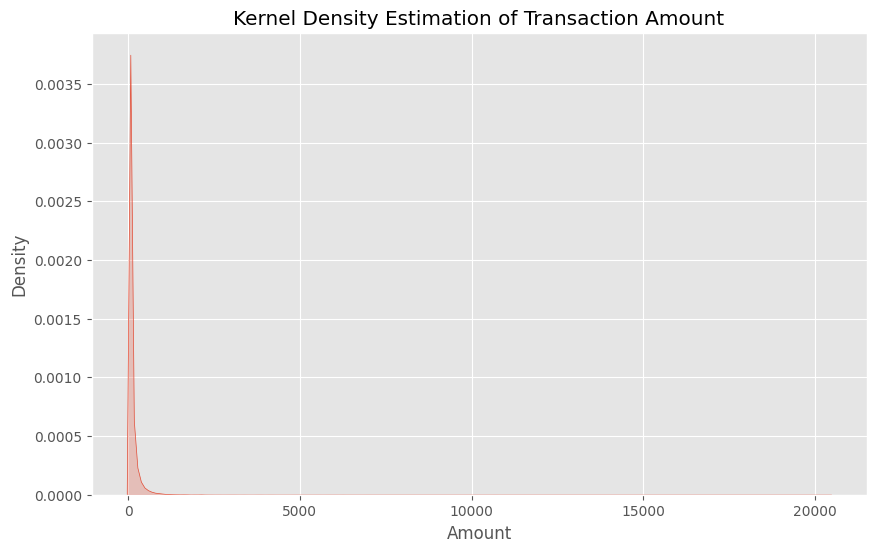

In [24]:
plt.figure(figsize=(10,6))

sns.kdeplot(df["Amount"], fill=True)

plt.title("Kernel Density Estimation of Transaction Amount")

plt.show()

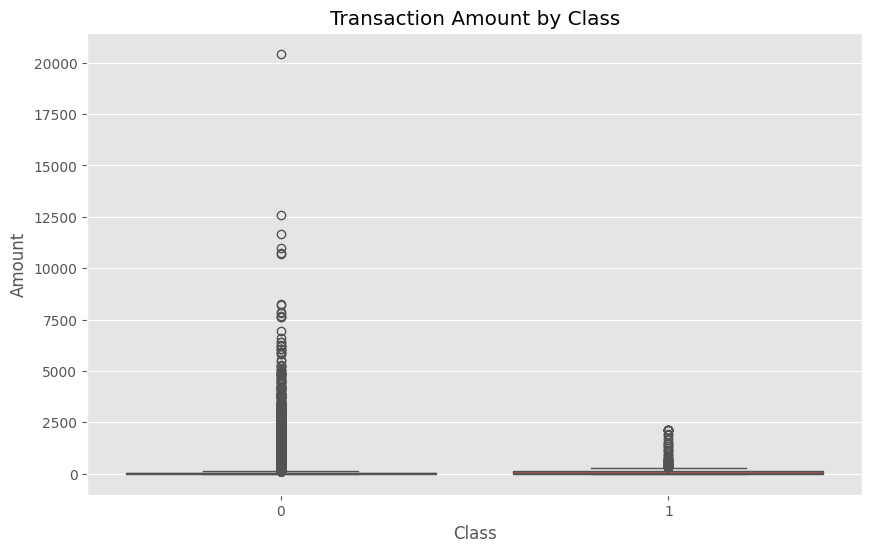

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")

plt.show()

In [26]:
fraud = df[df["Class"] == 1]
legitimate = df[df["Class"] == 0]

print("Average Fraud Amount")
print(fraud["Amount"].mean())

print()

print("Average Legitimate Amount")
print(legitimate["Amount"].mean())

Average Fraud Amount
163.2308840098736

Average Legitimate Amount
61.48118956752049


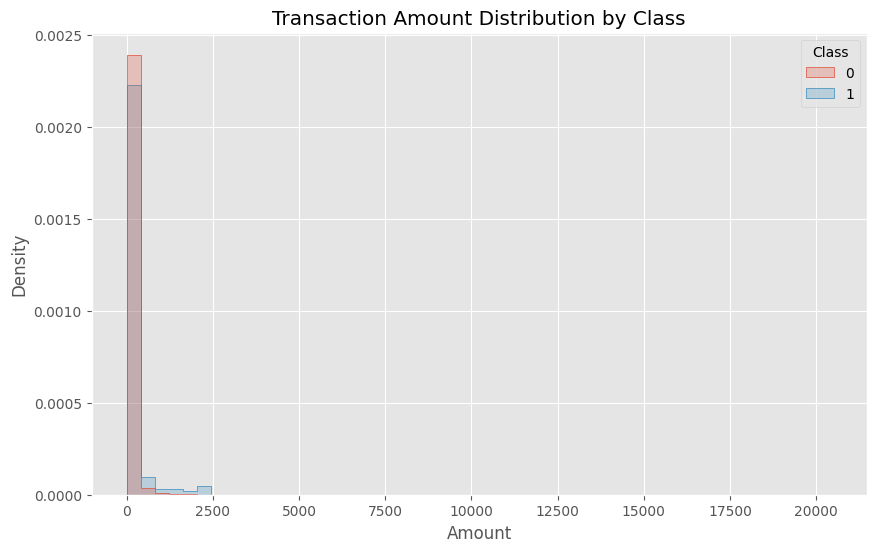

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution by Class")

plt.show()

In [28]:
amount_percentiles = df["Amount"].quantile([0.25,0.50,0.75,0.90,0.95,0.99])

amount_percentiles

0.25      7.256215
0.50     20.029080
0.75     55.037991
0.90    137.189219
0.95    236.338216
0.99    657.671897
Name: Amount, dtype: float64

## 📊 Observation

- Most transactions involve relatively small amounts.
- The transaction amount distribution is highly right-skewed.
- A small number of high-value transactions act as outliers.
- Fraudulent transactions occur across different transaction amounts and are not limited to high-value purchases.
- Feature scaling will be required before training machine learning models because the `Amount` feature has a much larger range than the PCA-transformed features.

In [29]:
df["Time"].describe()

count    284807.000000
mean      86484.695039
std       49874.319589
min           0.397108
25%       43236.711087
50%       86590.891761
75%      129648.084118
max      172790.624974
Name: Time, dtype: float64

In [30]:
print(f"Minimum Time : {df['Time'].min()} seconds")
print(f"Maximum Time : {df['Time'].max()} seconds")
print(f"Average Time : {df['Time'].mean():.2f} seconds")

Minimum Time : 0.3971075709465621 seconds
Maximum Time : 172790.6249736141 seconds
Average Time : 86484.70 seconds


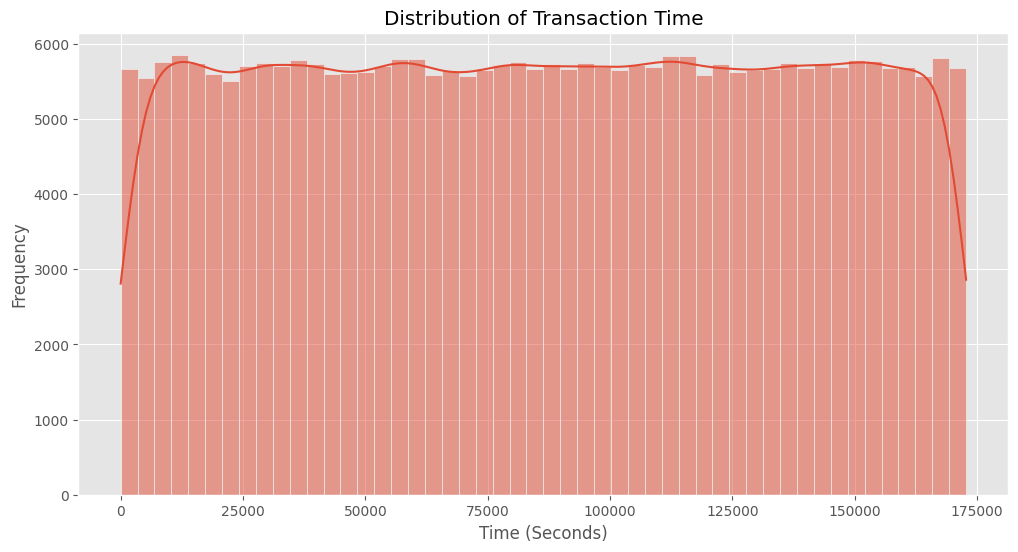

In [31]:
plt.figure(figsize=(12,6))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency")

plt.show()

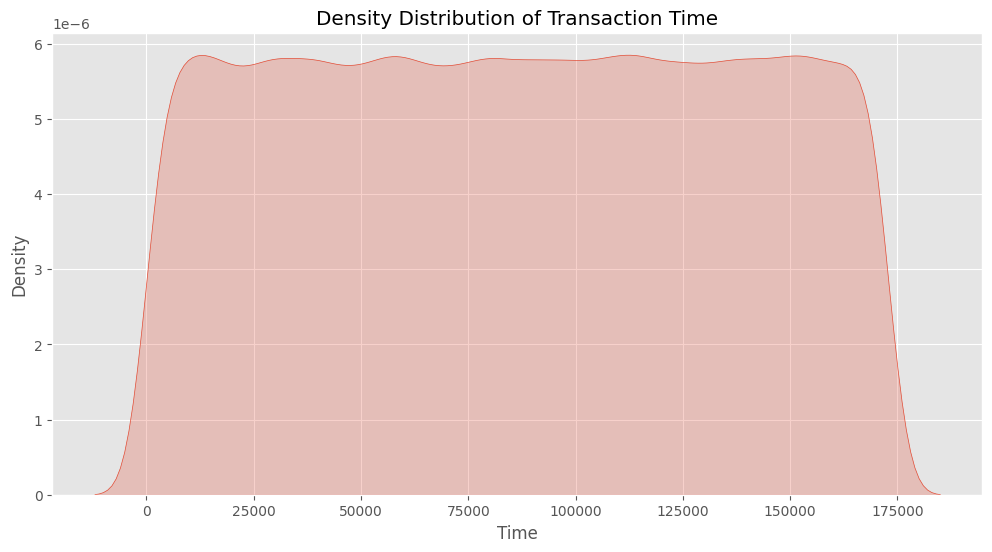

In [32]:
plt.figure(figsize=(12,6))

sns.kdeplot(df["Time"], fill=True)

plt.title("Density Distribution of Transaction Time")

plt.show()

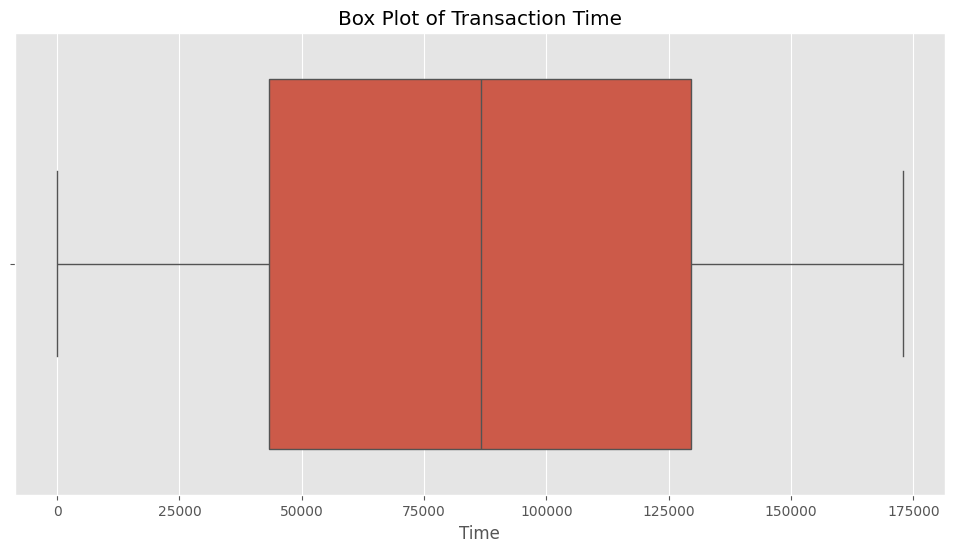

In [33]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df["Time"])

plt.title("Box Plot of Transaction Time")

plt.show()

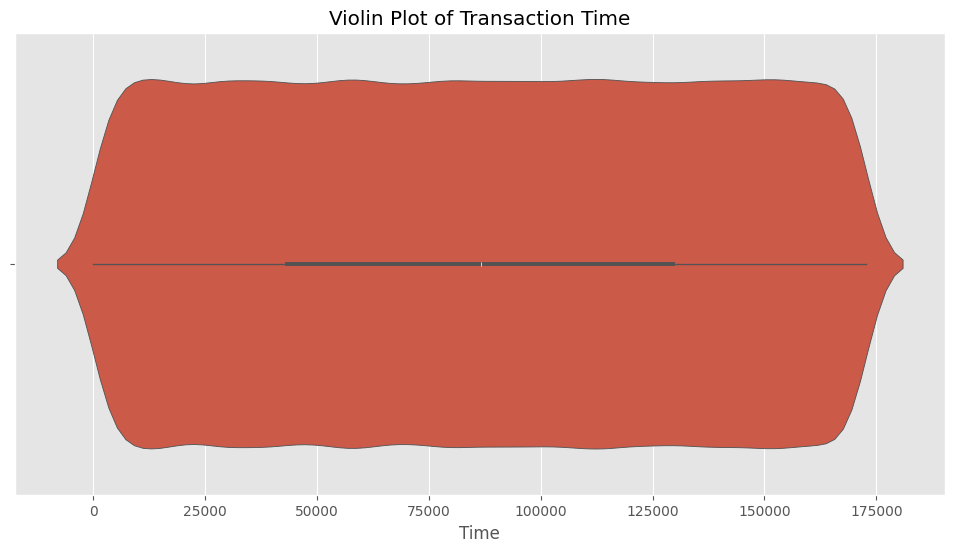

In [34]:
plt.figure(figsize=(12,6))

sns.violinplot(x=df["Time"])

plt.title("Violin Plot of Transaction Time")

plt.show()

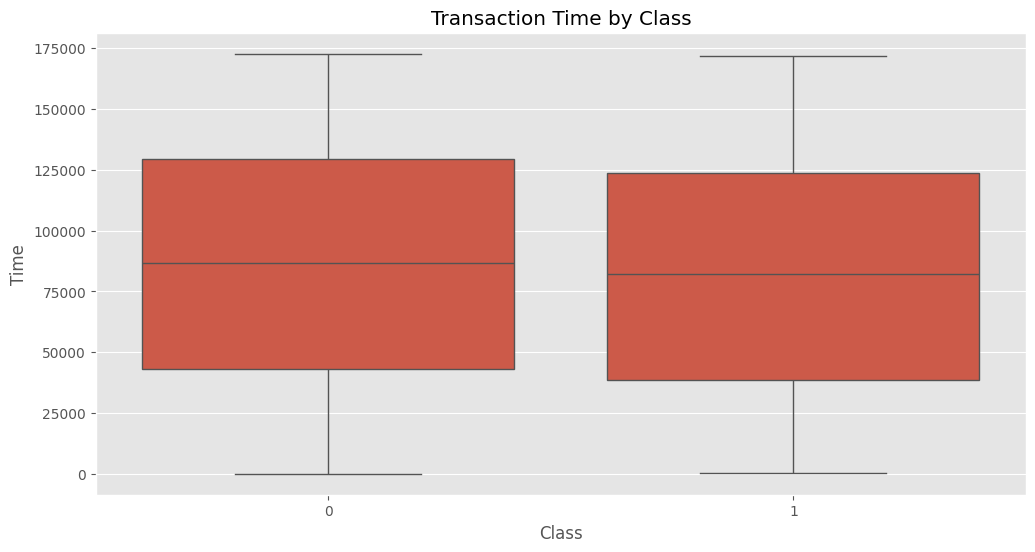

In [35]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Class",
    y="Time",
    data=df
)

plt.title("Transaction Time by Class")

plt.show()

In [36]:
fraud_time = df[df["Class"] == 1]["Time"]
legit_time = df[df["Class"] == 0]["Time"]

print("Average Fraud Time")
print(fraud_time.mean())

print()

print("Average Legitimate Time")
print(legit_time.mean())

Average Fraud Time
83032.17733176031

Average Legitimate Time
86490.66953412943


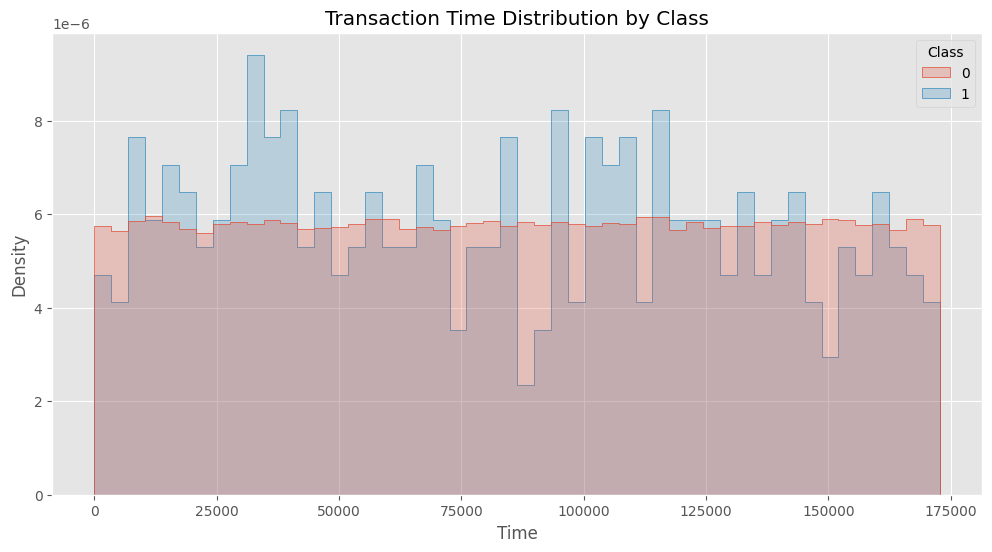

In [37]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")

plt.show()

In [38]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Hour"] = df["Hour"].astype(int)

df["Hour"].head()

0     8
1     8
2    23
3    19
4     1
Name: Hour, dtype: int32

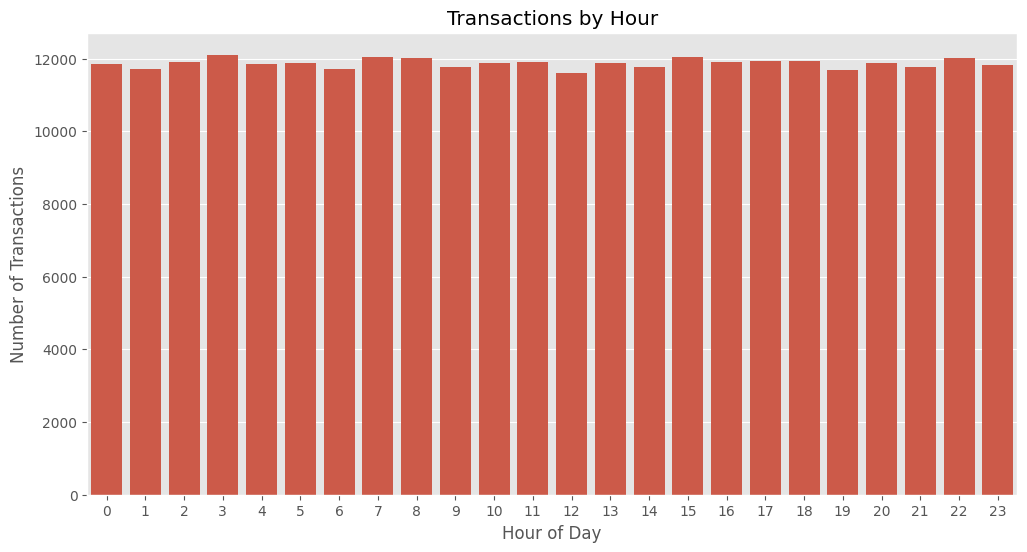

In [39]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="Hour",
    data=df
)

plt.title("Transactions by Hour")

plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

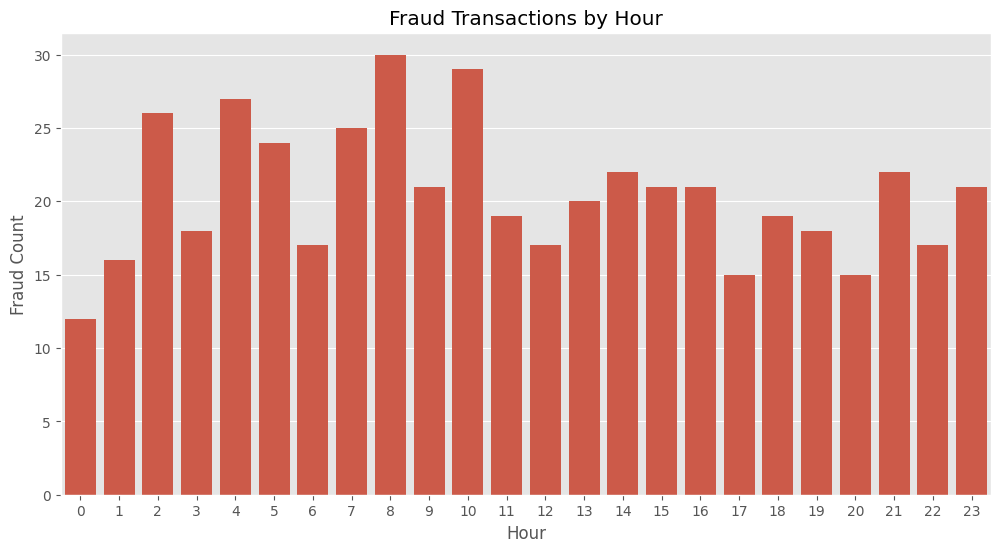

In [40]:
hourly_fraud = df.groupby("Hour")["Class"].sum().reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=hourly_fraud,
    x="Hour",
    y="Class"
)

plt.title("Fraud Transactions by Hour")

plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.show()

In [41]:
hourly_transactions = df.groupby("Hour").size().reset_index(name="Transactions")

hourly_transactions

,Hour,Transactions
0,0,11857
1,1,11700
2,2,11900
3,3,12104
4,4,11846
5,5,11864
6,6,11704
7,7,12033
8,8,12007
9,9,11769


In [42]:
hourly_fraud

,Hour,Class
0,0,12
1,1,16
2,2,26
3,3,18
4,4,27
5,5,24
6,6,17
7,7,25
8,8,30
9,9,21


# ⏱️ Observations

- Transactions are distributed throughout the available time period.
- Fraudulent transactions occur across multiple hours rather than being concentrated at a single time.
- Time alone is unlikely to separate fraud from legitimate transactions.
- Combining Time with other variables may improve model performance.
- We will keep this feature for model training after preprocessing.

In [43]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
Time,1.000000,0.002421,-0.001182,0.000317,-0.000979,-0.003391,0.002323,-0.002029,0.001033,0.000915,0.000461,-0.000499,0.001503,-0.000248,0.000581,-0.001986,-0.001534,0.000045,-0.001780,-0.001995,-0.001201,0.000229,0.000735,-0.000279,-0.000131,0.003333,0.002410,0.002725,-0.001327,0.000702,-0.002880,0.499218
V1,0.002421,1.000000,-0.028348,0.031060,-0.035317,0.008726,-0.000135,0.018650,-0.001711,0.010388,0.046631,-0.032621,0.054228,-0.001244,0.054830,-0.002625,0.034241,0.048610,0.014078,-0.013304,0.000867,-0.001738,0.003737,0.002687,-0.002509,0.000143,0.000839,0.000336,0.000399,-0.006957,-0.196998,-0.000526
V2,-0.001182,-0.028348,1.000000,-0.021160,0.024443,-0.007854,-0.001627,-0.008970,-0.002855,-0.012540,-0.032085,0.021090,-0.034490,-0.000895,-0.041750,-0.002218,-0.024645,-0.034266,-0.011005,0.009595,0.000727,-0.000317,0.000393,0.000352,0.002916,-0.000328,-0.000472,0.002802,-0.000916,0.003913,0.144441,-0.002103
V3,0.000317,0.031060,-0.021160,1.000000,-0.025150,0.009382,-0.003112,0.016620,0.002177,0.008493,0.037497,-0.027451,0.041276,0.000783,0.043267,-0.000215,0.028786,0.040316,0.016685,-0.008682,-0.004926,0.000751,0.000316,-0.000355,-0.005515,0.000147,0.000796,-0.002589,0.003635,-0.004672,-0.165106,0.001571
V4,-0.000979,-0.035317,0.024443,-0.025150,1.000000,-0.008285,0.001759,-0.011723,-0.001669,-0.012294,-0.045796,0.029334,-0.047968,0.000443,-0.052143,-0.001347,-0.030045,-0.045883,-0.017290,0.009995,-0.000509,-0.002504,-0.000334,-0.001262,0.004202,0.000870,0.001283,-0.004486,-0.000421,0.003182,0.184368,0.001456


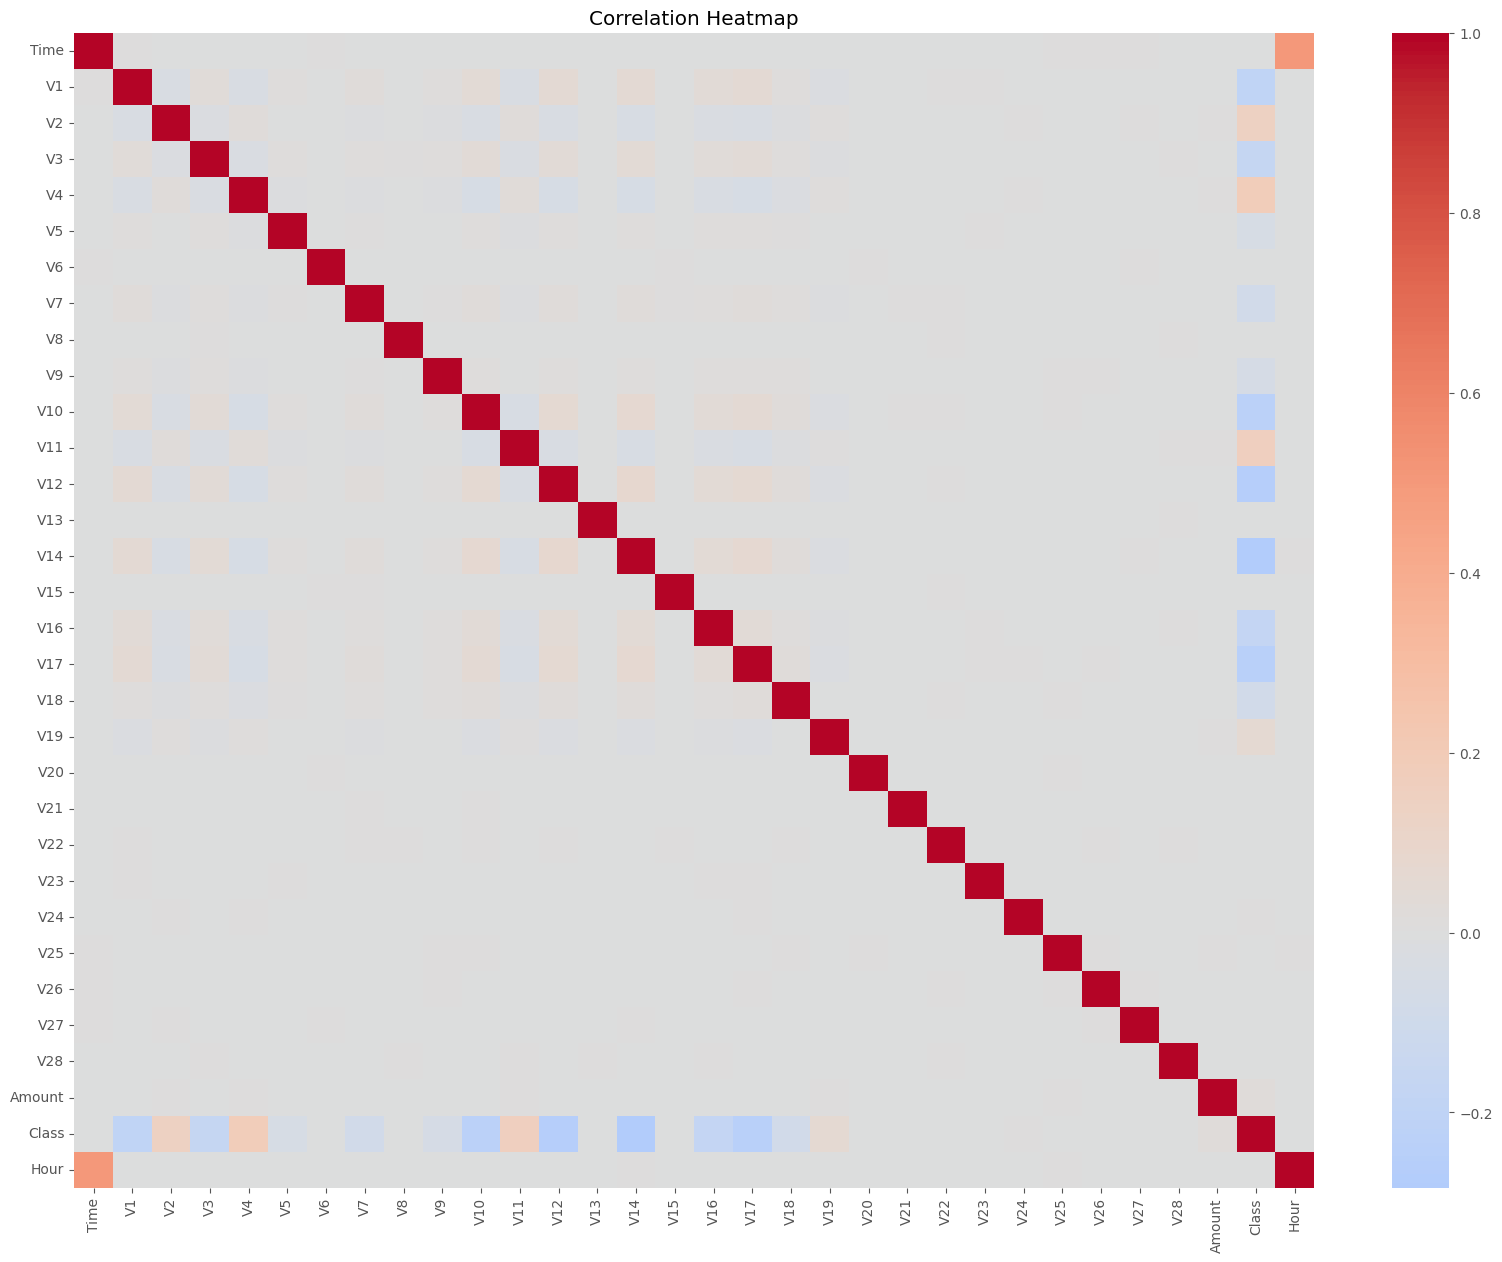

In [44]:
plt.figure(figsize=(20,15))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [45]:
target_corr = correlation_matrix["Class"].sort_values(ascending=False)

target_corr

Class     1.000000
V4        0.184368
V11       0.160459
V2        0.144441
V19       0.061432
Amount    0.023920
V24       0.004055
V15       0.001701
V13       0.001672
V28       0.001079
V25       0.000987
V20       0.000767
V8        0.000719
V6        0.000304
V22      -0.000007
V23      -0.000635
V21      -0.000881
V26      -0.000961
Hour     -0.001482
V27      -0.001583
Time     -0.002880
V5       -0.048951
V9       -0.057970
V18      -0.083903
V7       -0.085745
V3       -0.165106
V16      -0.171485
V1       -0.196998
V10      -0.230809
V17      -0.244703
V12      -0.257263
V14      -0.283721
Name: Class, dtype: float64

In [46]:
positive_corr = target_corr[1:11]

positive_corr

V4        0.184368
V11       0.160459
V2        0.144441
V19       0.061432
Amount    0.023920
V24       0.004055
V15       0.001701
V13       0.001672
V28       0.001079
V25       0.000987
Name: Class, dtype: float64

In [47]:
negative_corr = target_corr.tail(10)

negative_corr

V9    -0.057970
V18   -0.083903
V7    -0.085745
V3    -0.165106
V16   -0.171485
V1    -0.196998
V10   -0.230809
V17   -0.244703
V12   -0.257263
V14   -0.283721
Name: Class, dtype: float64

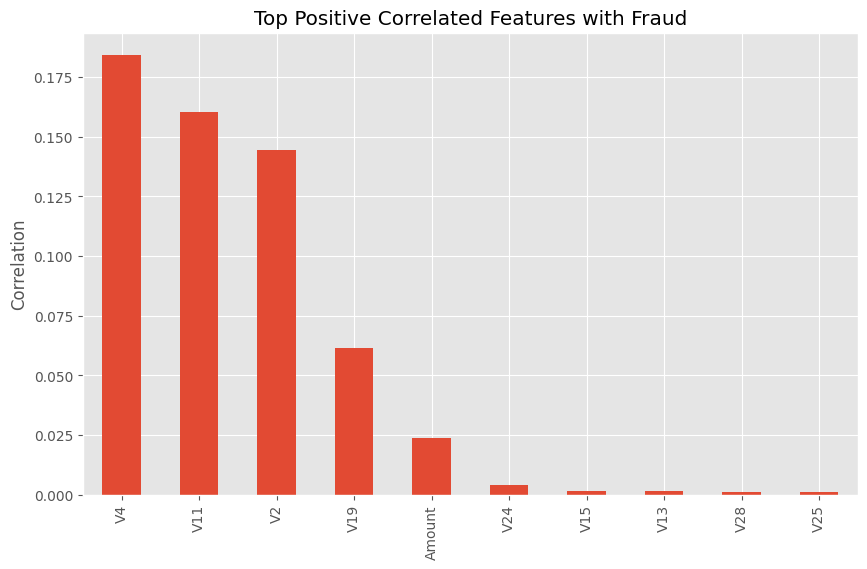

In [48]:
plt.figure(figsize=(10,6))

positive_corr.plot(kind="bar")

plt.title("Top Positive Correlated Features with Fraud")

plt.ylabel("Correlation")

plt.show()

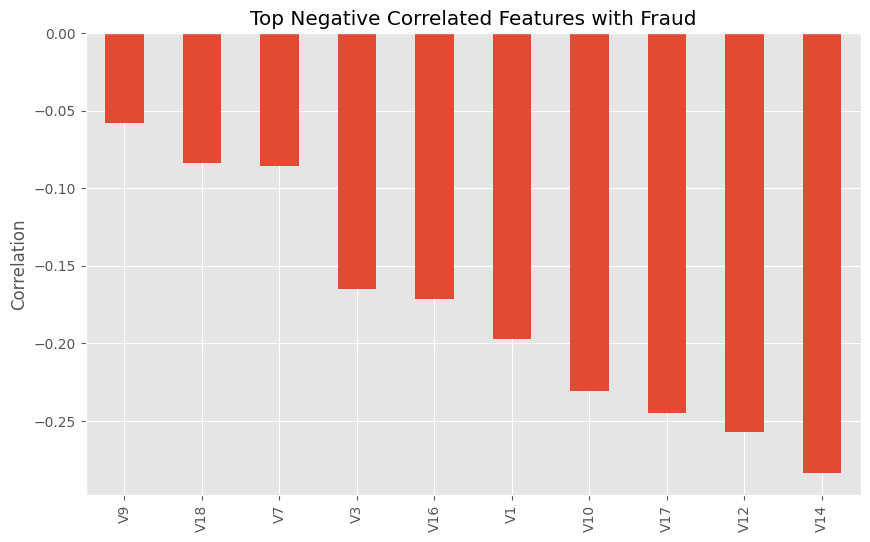

In [49]:
plt.figure(figsize=(10,6))

negative_corr.plot(kind="bar")

plt.title("Top Negative Correlated Features with Fraud")

plt.ylabel("Correlation")

plt.show()

In [50]:
top_features = target_corr.abs().sort_values(ascending=False).head(11).index

top_features

Index(['Class', 'V14', 'V12', 'V17', 'V10', 'V1', 'V4', 'V16', 'V3', 'V11',
       'V2'],
      dtype='object')

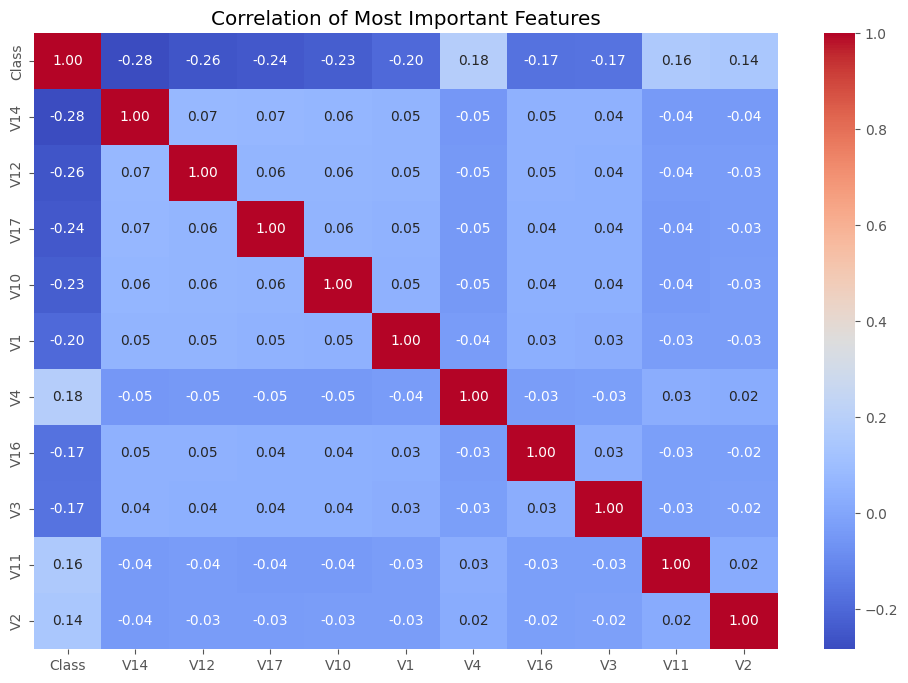

In [51]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Most Important Features")

plt.show()

In [52]:
target_corr.to_frame(name="Correlation with Class")

,Correlation with Class
Class,1.000000
V4,0.184368
V11,0.160459
V2,0.144441
V19,0.061432
Amount,0.023920
V24,0.004055
V15,0.001701
V13,0.001672
V28,0.001079


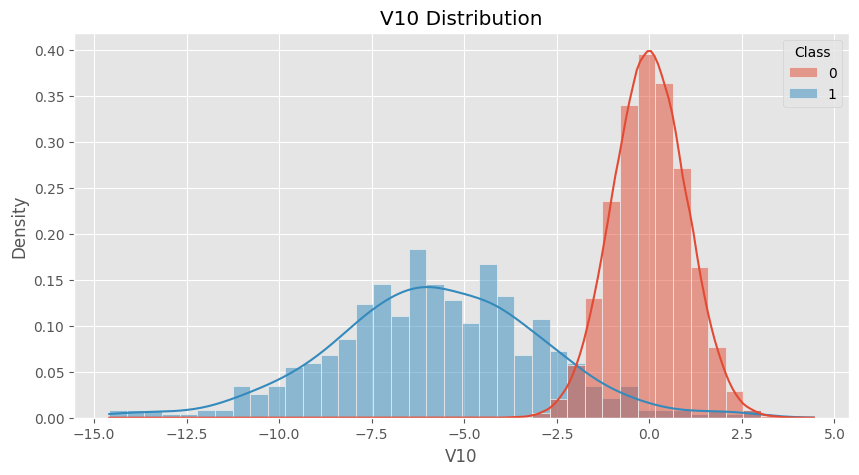

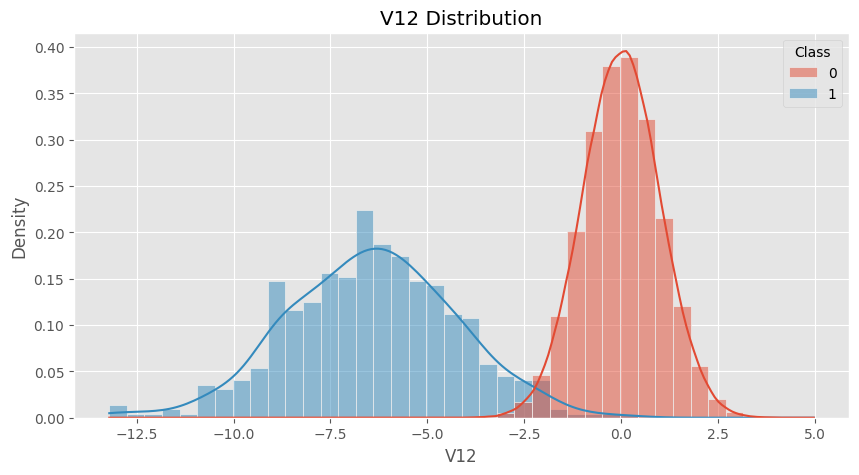

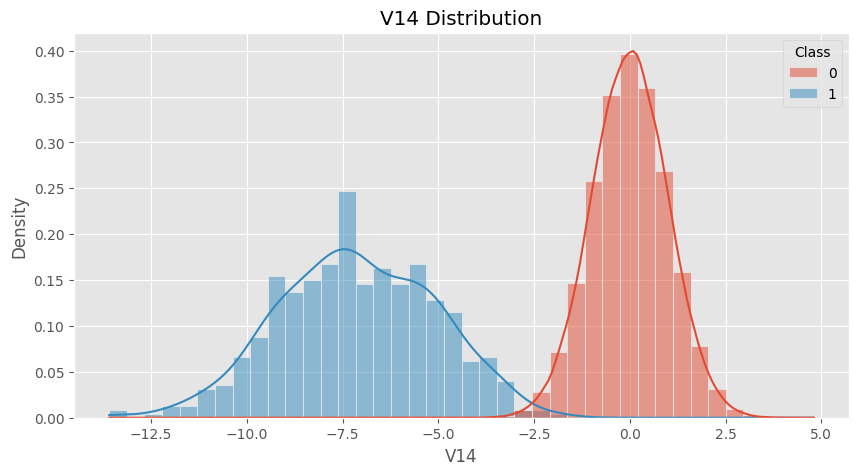

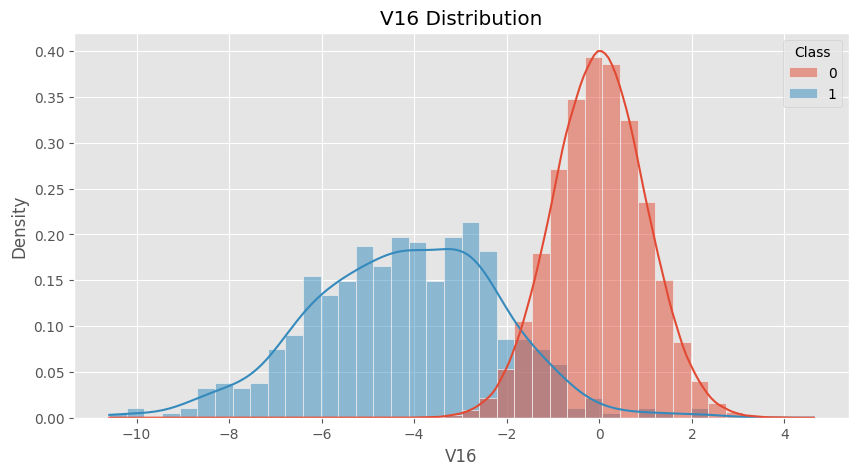

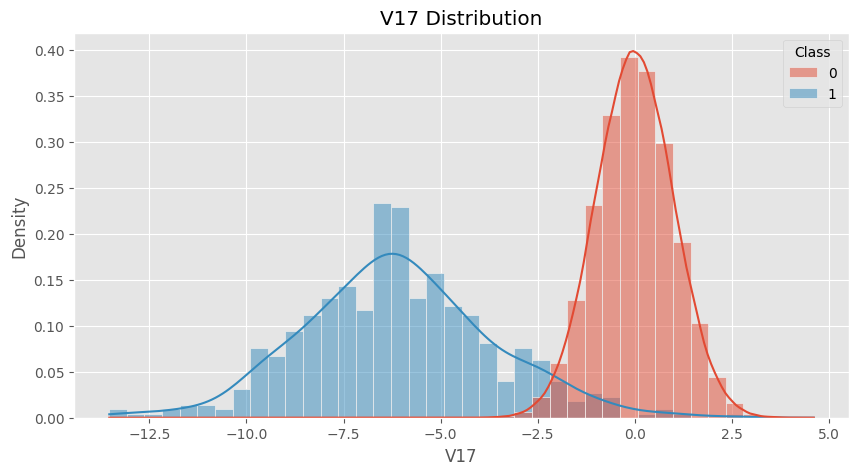

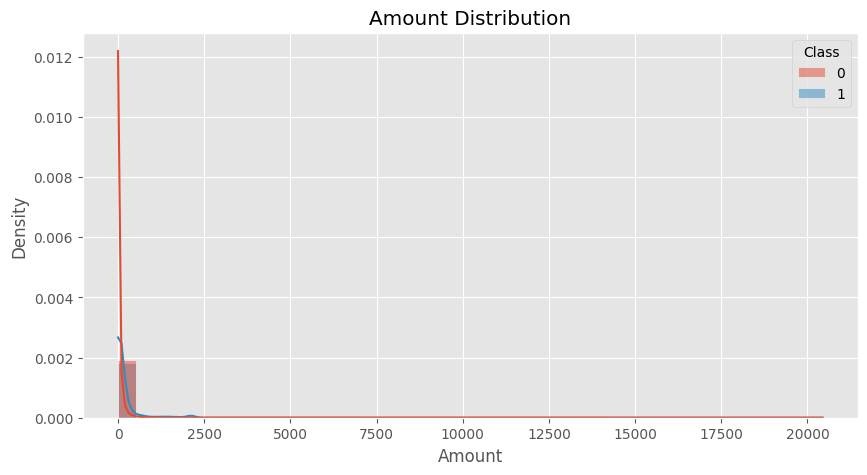

In [53]:
important_features = [
    "V10",
    "V12",
    "V14",
    "V16",
    "V17",
    "Amount"
]

for feature in important_features:

    plt.figure(figsize=(10,5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=40,
        kde=True,
        stat="density",
        common_norm=False
    )

    plt.title(f"{feature} Distribution")

    plt.show()

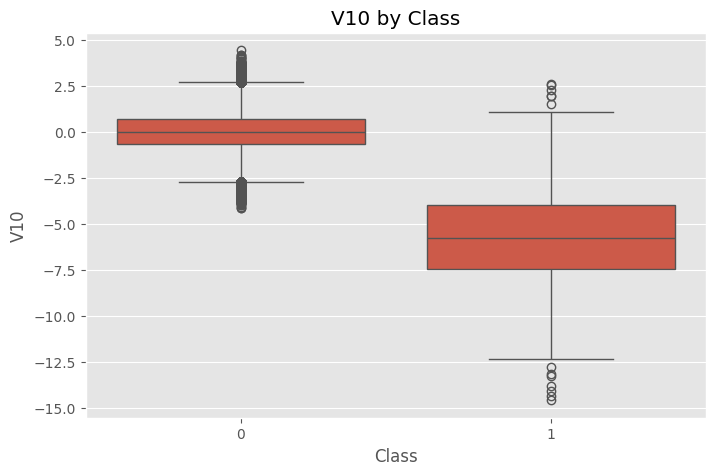

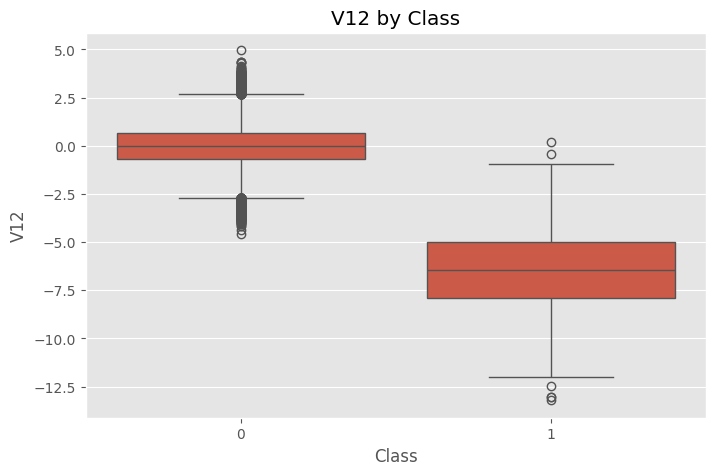

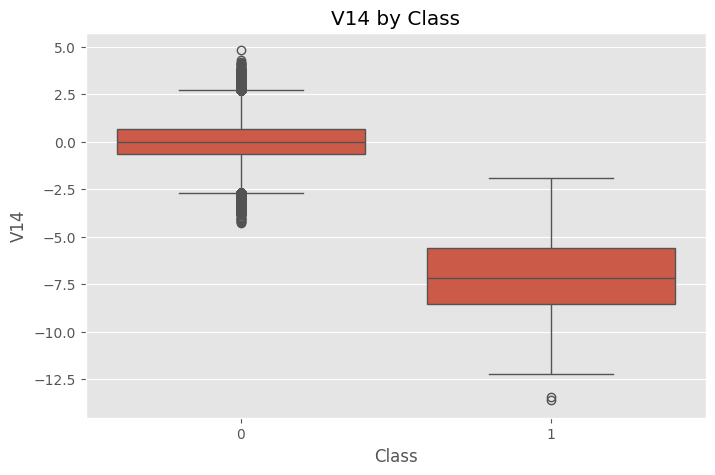

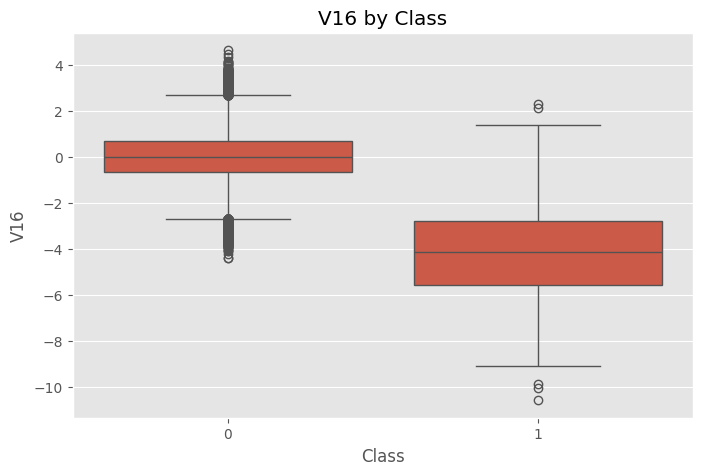

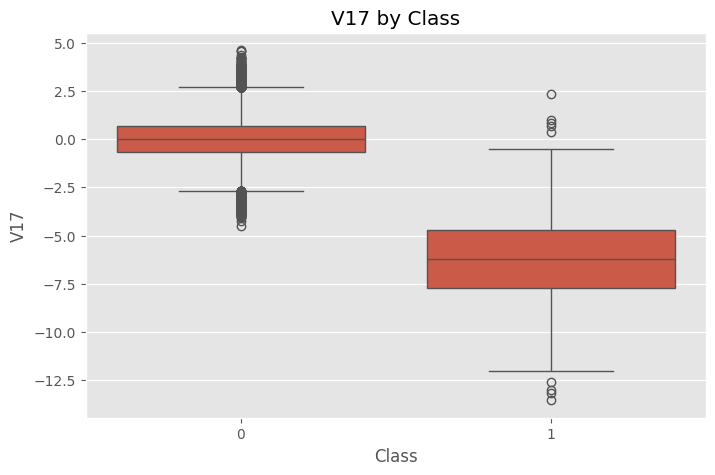

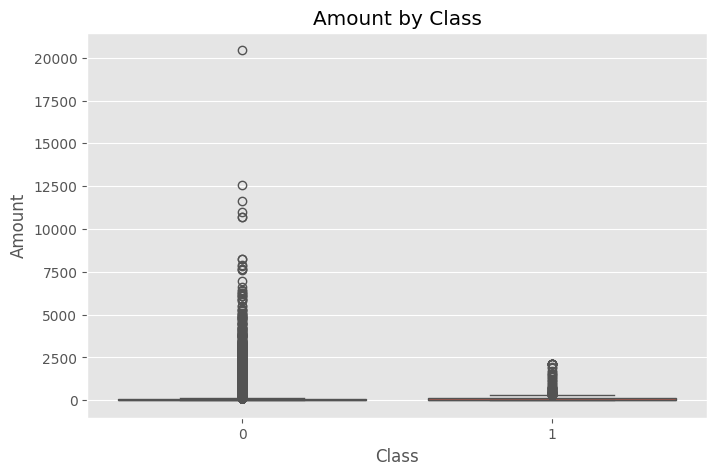

In [54]:
for feature in important_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.title(f"{feature} by Class")

    plt.show()

In [55]:
Q1 = df["Amount"].quantile(0.25)

Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount"] < lower) |
    (df["Amount"] > upper)
]

outliers.shape

(31234, 32)

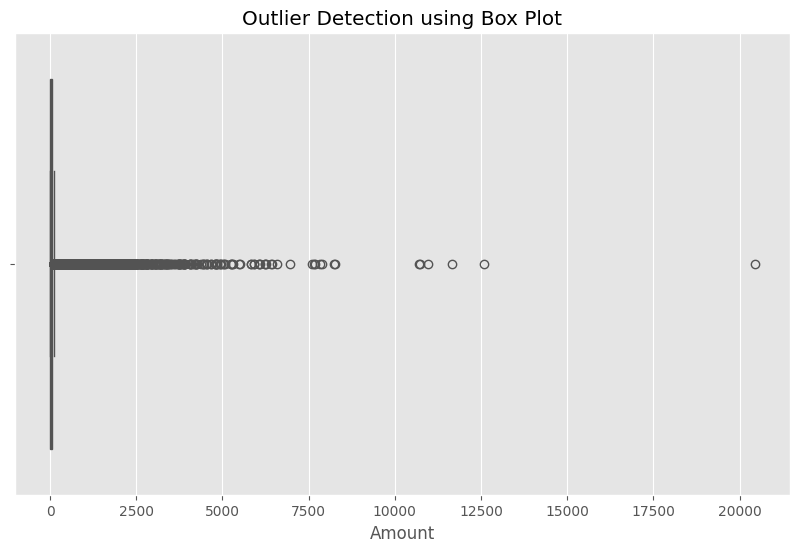

In [56]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["Amount"]
)

plt.title("Outlier Detection using Box Plot")

plt.show()

In [57]:
print(f"Lower Bound : {lower:.2f}")
print(f"Upper Bound : {upper:.2f}")
print(f"Outliers : {len(outliers)}")

Lower Bound : -64.42
Upper Bound : 126.71
Outliers : 31234


In [58]:
summary = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicates Removed": duplicates,
    "Fraud Cases": df["Class"].sum(),
    "Legitimate Cases": len(df) - df["Class"].sum(),
    "Fraud Percentage": round(df["Class"].mean()*100,4)
}

summary

{'Rows': 284807,
 'Columns': 32,
 'Missing Values': 0,
 'Duplicates Removed': 0,
 'Fraud Cases': 492,
 'Legitimate Cases': 284315,
 'Fraud Percentage': 0.1727}

In [59]:
pd.DataFrame(summary.items(), columns=["Metric","Value"])

,Metric,Value
0,Rows,284807.0000
1,Columns,32.0000
2,Missing Values,0.0000
3,Duplicates Removed,0.0000
4,Fraud Cases,492.0000
5,Legitimate Cases,284315.0000
6,Fraud Percentage,0.1727


# ✅ EDA Summary

## Key Findings

- The dataset is highly imbalanced, with fraud cases representing a very small percentage of all transactions.
- No missing values are present, making preprocessing simpler.
- Duplicate records were identified and removed.
- Transaction Amount is highly right-skewed and contains significant outliers.
- Transaction Time alone does not clearly distinguish fraudulent from legitimate transactions.
- Several PCA-transformed features (such as V10, V12, V14, V16, and V17) show stronger correlations with fraud than Amount or Time.
- Feature scaling will be applied before model training.
- Since the dataset is highly imbalanced, SMOTE will be used in the next notebook to improve model performance.